#1.Import Semua Packages/Library yang Digunakan

In [90]:
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


#2.Data Preparation

In [91]:
%%bash
mkdir -p ~/Downloads
curl -L -o ~/Downloads/image-classification-64-classes-animal.zip\
  https://www.kaggle.com/api/v1/datasets/download/anthonytherrien/image-classification-64-classes-animal

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 5851M  100 5851M    0     0  46.3M      0  0:02:06  0:02:06 --:--:-- 39.8M


In [92]:
# 1. Menentukan file sumber dan tujuan ekstraksi
local_zip = '/root/Downloads/image-classification-64-classes-animal.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')

# 2. Ekstraksi ke folder 'image-classification-64-classes-animal'
# It's better to extract to a folder with the same name as the dataset to avoid confusion.
zip_ref.extractall('./image-classification-64-classes-animal')
zip_ref.close()

In [93]:
base_dir = './image-classification-64-classes-animal/image'
total_all = 0

print("📂 image-classification-64-classes-animal/image")
print("."* 3+'\n')

folders = sorted(os.listdir(base_dir))
for i, folder in enumerate(folders):
    connector = "-"

    path = os.path.join(base_dir, folder)
    num_files = len(os.listdir(path))
    total_all += num_files

    print(f"{connector} 📂 {folder:<12} ({num_files} images)")

print(f"\nTotal images: {total_all}")

📂 image-classification-64-classes-animal/image
...

- 📂 antelope     (216 images)
- 📂 bear         (216 images)
- 📂 beaver       (216 images)
- 📂 bee          (216 images)
- 📂 bison        (216 images)
- 📂 blackbird    (216 images)
- 📂 buffalo      (216 images)
- 📂 butterfly    (216 images)
- 📂 camel        (216 images)
- 📂 cat          (432 images)
- 📂 cheetah      (216 images)
- 📂 chimpanzee   (216 images)
- 📂 chinchilla   (216 images)
- 📂 cow          (216 images)
- 📂 crab         (216 images)
- 📂 crocodile    (216 images)
- 📂 deer         (216 images)
- 📂 dog          (456 images)
- 📂 dolphin      (216 images)
- 📂 donkey       (216 images)
- 📂 duck         (216 images)
- 📂 eagle        (216 images)
- 📂 elephant     (288 images)
- 📂 falcon       (216 images)
- 📂 ferret       (216 images)
- 📂 flamingo     (216 images)
- 📂 fox          (216 images)
- 📂 frog         (312 images)
- 📂 giraffe      (216 images)
- 📂 goat         (216 images)
- 📂 goose        (216 images)
- 📂 gorilla      (

In [94]:
base_dir = './image-classification-64-classes-animal/image'
classes = sorted(os.listdir(base_dir))

# Setup plot 2 baris x 5 kolom
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

print("Menampilkan sampel gambar untuk verifikasi data...")

# Limit the loop to the number of available subplots
for i, class_name in enumerate(classes[:len(axes)]):
    class_path = os.path.join(base_dir, class_name)

    # Ambil file pertama di folder tersebut
    sample_file = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, sample_file)

    # Buka dan tampilkan
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {class_name}\nRes: {img.size}", fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

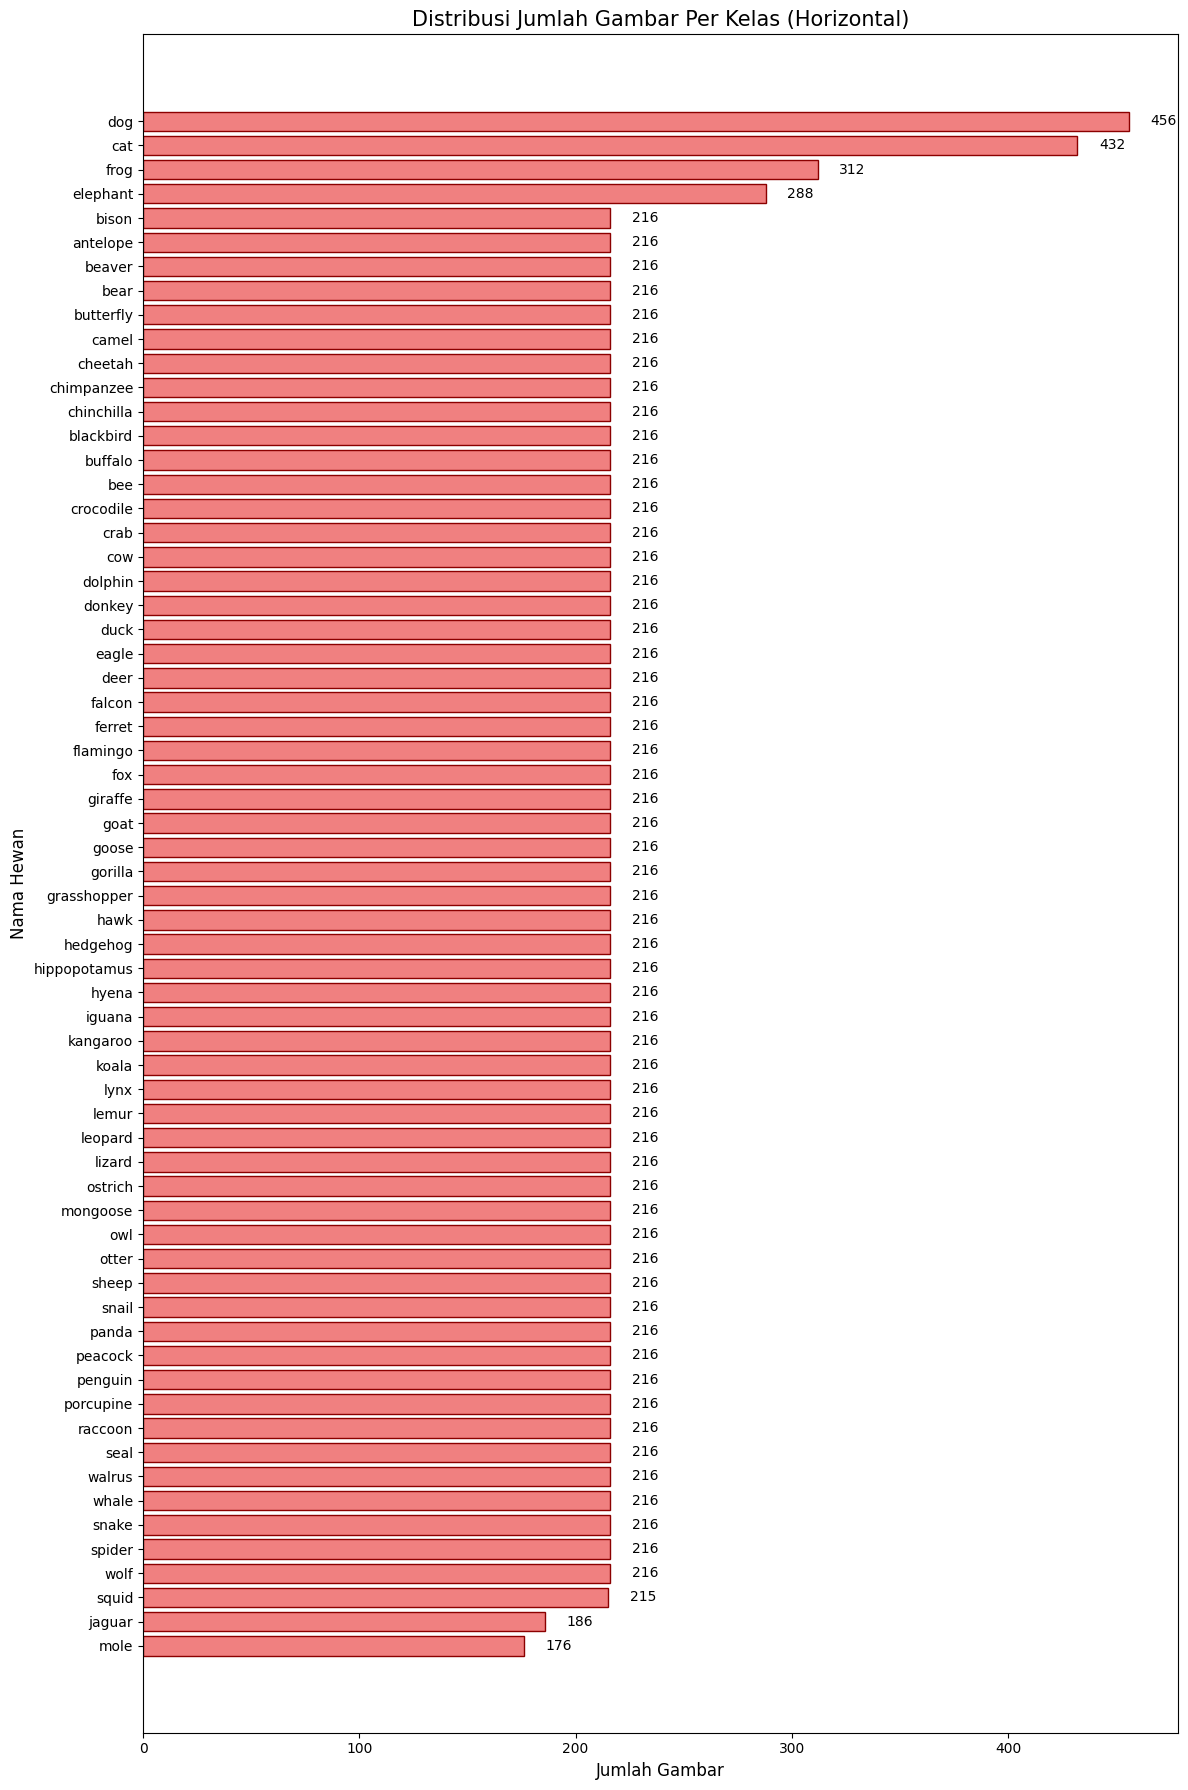

In [95]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# Prepare data from previous steps
base_dir = './image-classification-64-classes-animal/image'
labels = []
counts = []

folders = sorted(os.listdir(base_dir))
for folder in folders:
    path = os.path.join(base_dir, folder)
    num_files = len(os.listdir(path))
    labels.append(folder)
    counts.append(num_files)

# Create a DataFrame for easier sorting and plotting
df_counts = pd.DataFrame({'Label': labels, 'Count': counts})
df_counts = df_counts.sort_values(by='Count', ascending=False) # Sort by count for better visualization

plt.figure(figsize=(12, 18)) # Adjust figure size for horizontal plot
bars = plt.barh(df_counts['Label'], df_counts['Count'], color='lightcoral', edgecolor='darkred')
plt.title('Distribusi Jumlah Gambar Per Kelas (Horizontal)', fontsize=15)
plt.xlabel('Jumlah Gambar', fontsize=12)
plt.ylabel('Nama Hewan', fontsize=12)
plt.gca().invert_yaxis() # Invert y-axis to have the largest bar at the top

# Add counts next to the bars
for bar in bars:
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, int(bar.get_width()),
             va='center', ha='left')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#3.Data Preprocessing

In [96]:
import os
import shutil

# Define the base directory of the extracted images
original_base_dir = './image-classification-64-classes-animal/image'

# Define the new base directory for the filtered classes
filtered_base_dir = './filtered_animal_dataset'

# Define the selected classes (updated as per subtask instruction)
selected_classes = ['elephant', 'butterfly', 'snake', 'owl', 'crab', 'dolphin', 'giraffe', 'penguin', 'frog', 'grasshopper']

# --- Debugging Start ---
print(f"\n--- Debugging: Checking original paths ---")
print(f"Listing contents of {original_base_dir}:")
!ls -F {original_base_dir}
print(f"\nListing contents of a sample class folder ({selected_classes[0]}):")
!ls -F {os.path.join(original_base_dir, selected_classes[0])}
print(f"--- Debugging End ---\n")
# --- Debugging End ---

# Create the filtered_base_dir if it doesn't exist
if os.path.exists(filtered_base_dir):
    shutil.rmtree(filtered_base_dir) # Remove if exists to ensure clean start
os.makedirs(filtered_base_dir, exist_ok=True)

print(f"Copying images for selected classes: {selected_classes}")

for class_name in selected_classes:
    original_class_path = os.path.join(original_base_dir, class_name)
    filtered_class_path = os.path.join(filtered_base_dir, class_name)

    # Check if the original class path exists
    if os.path.exists(original_class_path):
        os.makedirs(filtered_class_path, exist_ok=True)
        # Copy all images from the original class path to the filtered class path
        for filename in os.listdir(original_class_path):
            shutil.copy(os.path.join(original_class_path, filename), filtered_class_path)
        print(f"- Copied {len(os.listdir(filtered_class_path))} images for class: {class_name}")
    else:
        print(f"Warning: Original class path not found for {class_name}: {original_class_path}")

print("Filtering complete. New dataset created at './filtered_animal_dataset'")

# Verify the new dataset structure and counts
print("\nVerifying filtered dataset:")
filtered_total_all = 0
if os.path.exists(filtered_base_dir):
    for folder in os.listdir(filtered_base_dir):
        path = os.path.join(filtered_base_dir, folder)
        if os.path.isdir(path):
            num_files = len(os.listdir(path))
            filtered_total_all += num_files
            print(f"- 📁 {folder:<12} ({num_files} images)")
    print(f"Total images in filtered dataset: {filtered_total_all}")
else:
    print(f"Filtered dataset directory not found: {filtered_base_dir}")


--- Debugging: Checking original paths ---
Listing contents of ./image-classification-64-classes-animal/image:
antelope/   chimpanzee/  elephant/     hawk/	      lynx/	  seal/
bear/	    chinchilla/  falcon/       hedgehog/      mole/	  sheep/
beaver/     cow/	 ferret/       hippopotamus/  mongoose/   snail/
bee/	    crab/	 flamingo/     hyena/	      ostrich/	  snake/
bison/	    crocodile/	 fox/	       iguana/	      otter/	  spider/
blackbird/  deer/	 frog/	       jaguar/	      owl/	  squid/
buffalo/    dog/	 giraffe/      kangaroo/      panda/	  walrus/
butterfly/  dolphin/	 goat/	       koala/	      peacock/	  whale/
camel/	    donkey/	 goose/        lemur/	      penguin/	  wolf/
cat/	    duck/	 gorilla/      leopard/       porcupine/
cheetah/    eagle/	 grasshopper/  lizard/	      raccoon/

Listing contents of a sample class folder (elephant):
00000-1644800467.png  00096-1644800563.png  00192-1644800659.png
00001-1644800468.png  00097-1644800564.png  00193-1644800660.png
00002-16448

In [97]:
import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the base directory of the filtered dataset
filtered_base_dir = './filtered_animal_dataset'

# Define the target number of images per class
target_images_per_class = 1000

# Initialize ImageDataGenerator for augmentation
# You can customize these parameters based on your needs
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("Memulai proses augmentasi data...")

# Iterate through each class in the filtered dataset
for class_name in os.listdir(filtered_base_dir):
    class_path = os.path.join(filtered_base_dir, class_name)
    if os.path.isdir(class_path):
        current_images = len(os.listdir(class_path))
        print(f"Kelas: {class_name} - Gambar saat ini: {current_images}")

        if current_images < target_images_per_class:
            images_to_generate = target_images_per_class - current_images
            print(f"  Diperlukan {images_to_generate} gambar tambahan.")

            # Load images for the current class
            # Use a dummy batch size of 1 to generate one image at a time until target is met
            generator = datagen.flow_from_directory(
                filtered_base_dir,
                classes=[class_name], # Only flow images for this specific class
                target_size=(150, 150), # Specify a target size for augmentation (can be adjusted)
                batch_size=1,
                class_mode=None, # We are just generating images, not fitting a model
                save_to_dir=class_path, # Save augmented images directly to the class folder
                save_prefix='aug',
                save_format='png'
            )

            # Generate images until the target is reached
            i = 0
            for _ in generator:
                i += 1
                if i >= images_to_generate:
                    break
            print(f"  {i} gambar augmented telah dihasilkan untuk kelas {class_name}.")
        else:
            print(f"  Jumlah gambar sudah mencukupi atau lebih dari {target_images_per_class}.")

print("Proses augmentasi selesai.")

# Verify the new counts after augmentation
print("\nMemverifikasi jumlah gambar setelah augmentasi:")
augmented_total_all = 0
for folder in os.listdir(filtered_base_dir):
    path = os.path.join(filtered_base_dir, folder)
    if os.path.isdir(path):
        num_files = len(os.listdir(path))
        augmented_total_all += num_files
        print(f"- 📁 {folder:<12} ({num_files} images)")
print(f"Total gambar di dataset augmented: {augmented_total_all}")

Memulai proses augmentasi data...
Kelas: snake - Gambar saat ini: 216
  Diperlukan 784 gambar tambahan.
Found 216 images belonging to 1 classes.
  784 gambar augmented telah dihasilkan untuk kelas snake.
Kelas: elephant - Gambar saat ini: 288
  Diperlukan 712 gambar tambahan.
Found 288 images belonging to 1 classes.
  712 gambar augmented telah dihasilkan untuk kelas elephant.
Kelas: dolphin - Gambar saat ini: 216
  Diperlukan 784 gambar tambahan.
Found 216 images belonging to 1 classes.
  784 gambar augmented telah dihasilkan untuk kelas dolphin.
Kelas: grasshopper - Gambar saat ini: 216
  Diperlukan 784 gambar tambahan.
Found 216 images belonging to 1 classes.
  784 gambar augmented telah dihasilkan untuk kelas grasshopper.
Kelas: owl - Gambar saat ini: 216
  Diperlukan 784 gambar tambahan.
Found 216 images belonging to 1 classes.
  784 gambar augmented telah dihasilkan untuk kelas owl.
Kelas: frog - Gambar saat ini: 312
  Diperlukan 688 gambar tambahan.
Found 312 images belonging to

In [98]:
import splitfolders
import shutil
import os

# 1. Tentukan folder input (dataset yang sudah diaugmentasi)
input_folder = './filtered_animal_dataset'
output_folder = './dataset_final'

# Pastikan output folder bersih sebelum split baru
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

# 2. Proses Splitting dengan 3 rasio (Train, Val, Test)
# Ini akan membagi semua kelas di input_folder
splitfolders.ratio(input_folder, output=output_folder,
                   seed=1337, ratio=(.8, .1, .1),
                   group_prefix=None, move=False)

print("Pemisahan Selesai! Sekarang Anda punya folder Train, Val, dan Test dengan kelas yang sudah diaugmentasi.")

Copying files: 10000 files [00:04, 2067.46 files/s]

Pemisahan Selesai! Sekarang Anda punya folder Train, Val, dan Test dengan kelas yang sudah diaugmentasi.


#4.Split Dataset

In [99]:
import os

output_folder = './dataset_final'
subfolders = ['train', 'val', 'test']
classes = ['elephant', 'butterfly', 'snake', 'owl', 'crab', 'dolphin', 'giraffe', 'penguin', 'frog', 'grasshopper'] # Updated with our actual selected classes

# Hitung total keseluruhan dulu untuk persentase total
grand_total = 0
for sub in subfolders:
    for cls in classes:
        path = os.path.join(output_folder, sub, cls)
        # Ensure path exists before listing contents
        if os.path.exists(path):
            grand_total += len(os.listdir(path))

# Format header secara dinamis
header = f"{'Folder':<10} | " + " | ".join([f"{c:<10}" for c in classes]) + f" | {'Total':<10} | {'Persentase'}"
print(header)
print("-" * (10 + 3 * (len(classes) * 10 + len(classes) - 1) + 10 + 10 + 12))

for sub in subfolders:
    counts = []
    for cls in classes:
        path = os.path.join(output_folder, sub, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        counts.append(count)

    row_total = sum(counts)
    percentage = (row_total / grand_total) * 100 if grand_total > 0 else 0

    # Format baris data secara dinamis
    row_str = f"{sub.upper():<10} | " + " | ".join([f"{c:<10}" for c in counts]) + f" | {row_total:<10} | {percentage:.1f}%"
    print(row_str)

print("-" * (10 + 3 * (len(classes) * 10 + len(classes) - 1) + 10 + 10 + 12))

# Calculate column totals for GRAND TOTAL row
col_totals = []
for cls in classes:
    class_total = 0
    for sub in subfolders:
        path = os.path.join(output_folder, sub, cls)
        class_total += len(os.listdir(path)) if os.path.exists(path) else 0
    col_totals.append(class_total)

# Print GRAND TOTAL row
print(f"{'GRAND TOTAL':<10} | " + " | ".join([f"{t:<10}" for t in col_totals]) + f" | {grand_total:<10}")

Folder     | elephant   | butterfly  | snake      | owl        | crab       | dolphin    | giraffe    | penguin    | frog       | grasshopper | Total      | Persentase
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
TRAIN      | 800        | 800        | 800        | 800        | 800        | 800        | 800        | 800        | 800        | 800        | 8000       | 80.0%
VAL        | 100        | 100        | 100        | 100        | 100        | 100        | 100        | 100        | 100        | 100        | 1000       | 10.0%
TEST       | 100        | 100        | 100        | 100        | 100        | 100        | 100        | 100        | 100        | 100     

In [100]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

print("Memulai pemuatan dataset dari direktori...")

# Memuat Train Set
train_ds = tf.keras.utils.image_dataset_from_directory(
    './dataset_final/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Memuat Validation Set
val_ds = tf.keras.utils.image_dataset_from_directory(
    './dataset_final/val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Memuat Test Set
test_ds = tf.keras.utils.image_dataset_from_directory(
    './dataset_final/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Memulai pemuatan dataset dari direktori...
Found 8000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.


#5.Modelling

In [101]:
import tensorflow as tf

# 1. Menggunakan transfer learning MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# 2. Arsitektur Model
model = tf.keras.models.Sequential([

    # Explicit Input layer to avoid UserWarning for Rescaling layer
    tf.keras.Input(shape=(150, 150, 3)),
    # Layer Preprocessing
    tf.keras.layers.Rescaling(scale=1./127.5, offset=-1),
    # data_augmentation, # Kita sudah melakukan augmentasi secara offline, jadi ini tidak lagi diperlukan di sini.

    # Transfer Learning
    base_model,

    # Conv2D & Pooling Layer
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Layer Klasifikasi
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(classes), activation='softmax') # Corrected to len(classes) for 10 output classes
])

# 3. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callback Lebih Cerdas
class TargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.96 and logs.get('val_accuracy') > 0.96):
            print("\n...")
            self.model.stop_training = True

my_callbacks = [
    TargetCallback(),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
]
print("Model redefined and recompiled for 10 classes.")

/tmp/ipykernel_666/2427409048.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model redefined and recompiled for 10 classes.


#6.Training Model

In [102]:
print("Memulai ...")
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=my_callbacks
)

Memulai ...
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9291 - loss: 0.3753
...
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - accuracy: 0.9293 - loss: 0.3743 - val_accuracy: 0.9980 - val_loss: 0.0236 - learning_rate: 0.0010


#7.Evaluasi Model

In [103]:
print("--- Evaluasi Model pada Data Test ---")

test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Hasil Akurasi Data Test: {test_accuracy * 100:.2f}%")
print(f"Hasil Loss Data Test: {test_loss:.4f}")

--- Evaluasi Model pada Data Test ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9975 - loss: 0.0279
Hasil Akurasi Data Test: 99.50%
Hasil Loss Data Test: 0.0426


#8.Visualisasikan

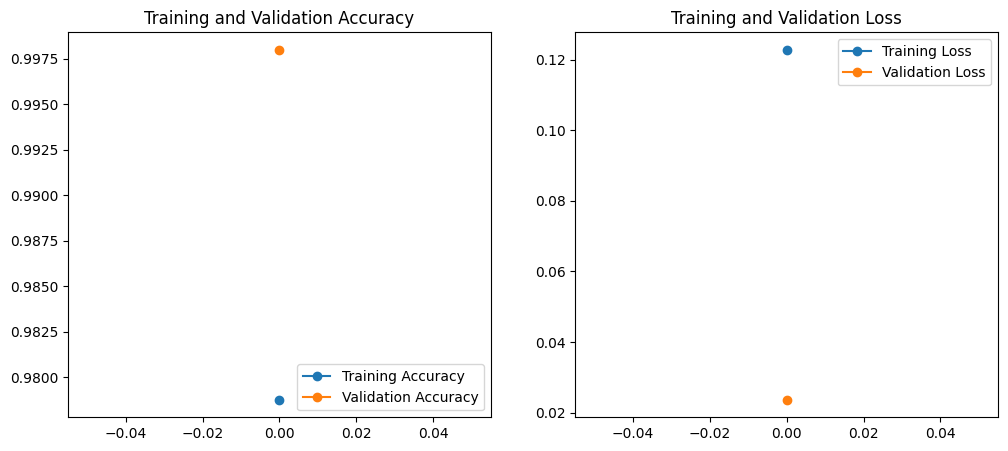

In [104]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Plot Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o') # Added marker
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o') # Added marker
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o') # Added marker
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o') # Added marker
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step


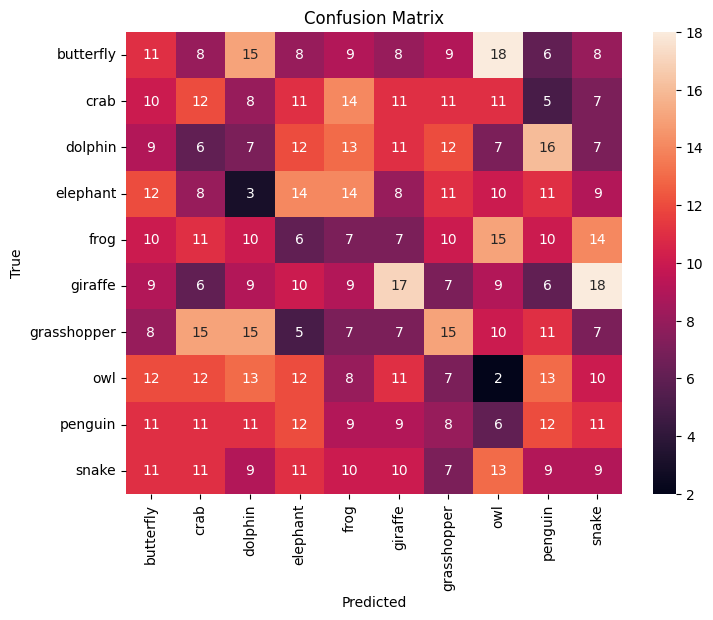

In [109]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Prediksi test data
Y_pred = model.predict(test_ds)
y_pred = np.argmax(Y_pred, axis=1);

# True label
y_true = []
for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true);

# Class names (assuming they are in alphabetical order as loaded by image_dataset_from_directory)
class_names = test_ds.class_names

# Confusion matrix
cm = confusion_matrix(y_true, y_pred);

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

#9.Simpan & Konversi Model

In [105]:
base_dir = 'submission'

sub_folders = [
    'saved_model',
    'tfjs_model',
    'tflite'
]

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)


for folder in sub_folders:
    path = os.path.join(base_dir, folder)
    os.makedirs(path, exist_ok=True)

print("selesai")

selesai


In [111]:
import tensorflowjs as tfjs

# A. Simpan sebagai .keras
model.save('submission/my_model.keras')

# B. Simpan sebagai SavedModel
model.export('submission/saved_model')

# C. Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

# D. Konversi ke TFJS
# Ensure tensorflowjs is installed. If not, uncomment and run:
# !pip install tensorflowjs
tfjs.converters.save_keras_model(model, 'submission/tfjs_model')

print("selesai!")

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_6086')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  138985871354448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138985871357712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138985871354064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138985871356176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138985871355024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138985871353104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138985871357328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138985871357904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138985871356368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138985871355984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13

failed to lookup keras version from the file,
    this is likely a weight only file
selesai!


#10.Uji model dengan data test menggunakan 9 inference dan 1 Inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


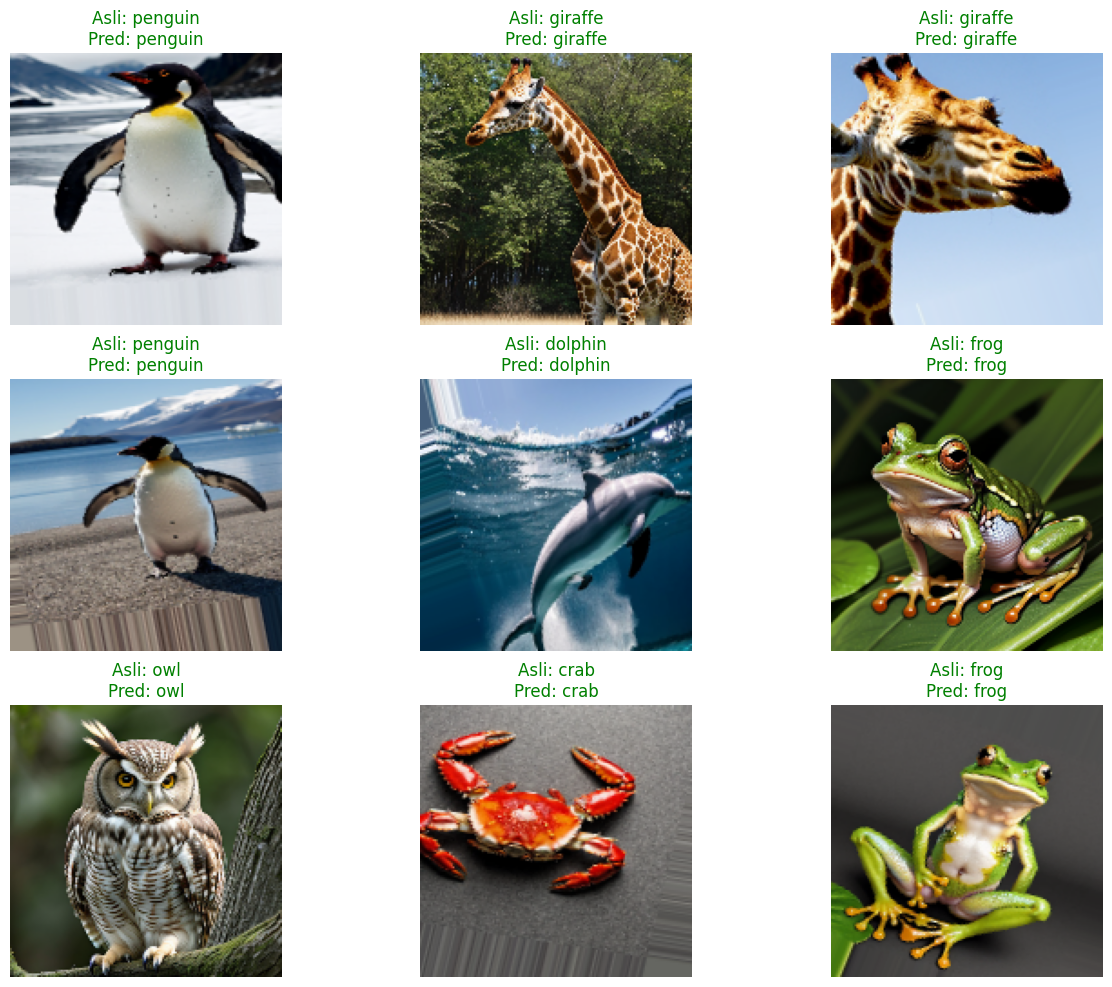

In [112]:
loaded_model = tf.keras.models.load_model('submission/my_model.keras')

# Ambil sampel data dari test_ds
for images, labels in test_ds.take(1):
    predictions = loaded_model.predict(images)
    class_names = test_ds.class_names # Dynamically retrieve class names from test_ds for correct order

    plt.figure(figsize=(15, 12))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        actual_idx = np.argmax(labels[i])
        pred_idx = np.argmax(predictions[i])

        color = 'green' if actual_idx == pred_idx else 'red'
        plt.title(f"Asli: {class_names[actual_idx]}\nPred: {class_names[pred_idx]}", color=color)
        plt.axis('off')
    plt.show()

In [113]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Ambil satu batch dari test_ds
for img_batch, label_batch in test_ds.take(1):
    # Ambil satu gambar dan label dari batch tersebut
    img_sample = img_batch[0]
    label_sample = label_batch[0]
    break

# Ubah tensor gambar kembali ke format PIL Image untuk visualisasi (jika perlu)
# Atau langsung gunakan img_sample untuk prediksi jika model menerima tensor

# Untuk prediksi, kita memerlukan img_array dalam bentuk batch (1, height, width, channels)
img_array = np.expand_dims(img_sample, axis=0)

# Dapatkan nama kelas aktual dari label_sample
class_names = test_ds.class_names # Menggunakan class_names dari test_ds
actual_class_idx = np.argmax(label_sample.numpy())
actual_class_name = class_names[actual_class_idx]

print(f"Gambar sampel telah disiapkan dari kelas aktual: {actual_class_name}")

Gambar sampel telah disiapkan dari kelas aktual: snake


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Class : snake
Confidence      : 1.0
Actual Class    : snake


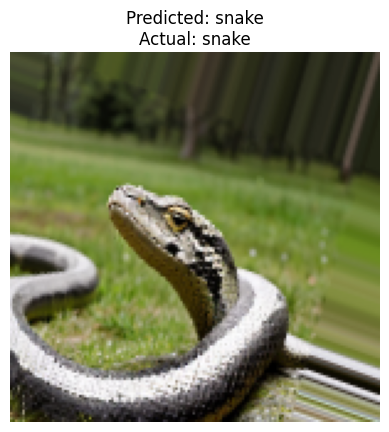

In [114]:
# Variabel yang dibutuhkan dari sel sebelumnya:
# img_array
# actual_class_name
# class_names (dari test_ds.class_names)

prediction = model.predict(img_array)
predicted_class_idx = np.argmax(prediction)
confidence = np.max(prediction)

# Gunakan class_names yang sudah didapatkan dari test_ds
class_labels = class_names

print("Predicted Class :", class_labels[predicted_class_idx])
print("Confidence      :", confidence)
print("Actual Class    :", actual_class_name)

plt.imshow(img_array[0].astype("uint8")) # Tampilkan gambar
plt.title(f"Predicted: {class_labels[predicted_class_idx]}\nActual: {actual_class_name}")
plt.axis("off")
plt.show()

#11.Save File Requirment


In [119]:
import matplotlib # Added this import
import sklearn # Added this import for sklearn.__version__

# Membuat dictionary untuk library utama
dependencies = {
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "tensorflow": tf.__version__,
    "matplotlib": matplotlib.__version__, # Menggunakan matplotlib.__version__ yang benar
    "seaborn": sns.__version__,
    "scikit-learn": sklearn.__version__,
    "Pillow": Image.__version__, # Menggunakan versi dari PIL
    "tensorflowjs": tfjs.__version__ # Menggunakan versi dari tfjs
}

print("--- Hasil Pengecekan Versi Library ---")
for lib, ver in dependencies.items():
    print(f"{lib.ljust(18)} : {ver}")

# Membuat file requirements.txt secara otomatis
with open("requirements.txt", "w") as f:
    for lib, ver in dependencies.items():
        f.write(f"{lib}=={ver}\n")
    # Menambahkan library yang tidak punya __version__ standar atau belum diimpor dengan alias
    f.write("split-folders\n")

print("\n[SUKSES] File 'requirements.txt' siap di-download!")

--- Hasil Pengecekan Versi Library ---
pandas             : 2.2.2
numpy              : 2.0.2
tensorflow         : 2.19.0
matplotlib         : 3.10.0
seaborn            : 0.13.2
scikit-learn       : 1.6.1
Pillow             : 11.3.0
tensorflowjs       : 4.22.0

[SUKSES] File 'requirements.txt' siap di-download!


In [121]:
from google.colab import drive
import shutil
import os

# 1. Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Tentukan jalur folder sumber dan tujuan
source_folder = './submission'
destination_folder = '/content/drive/MyDrive/my_animal_classification_submission' a

# 3. Buat folder tujuan di Google Drive jika belum ada
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)

# 4. Salin seluruh isi folder 'submission' ke Google Drive
print(f"Copying '{source_folder}' to '{destination_folder}'...")
shutil.copytree(source_folder, destination_folder, dirs_exist_ok=True)

print("Folder 'submission' berhasil disimpan ke Google Drive Anda!")
print(f"Anda dapat menemukannya di: {destination_folder}")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying './submission' to '/content/drive/MyDrive/my_animal_classification_submission'...
Folder 'submission' berhasil disimpan ke Google Drive Anda!
Anda dapat menemukannya di: /content/drive/MyDrive/my_animal_classification_submission
